# Function 4 Analysis - Week 9

**Function description:** Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

**Week 8 evaluated point:** `(0.436923, 0.340000, 0.380000, 0.407241)` returned **y ≈ 0.262**, well below our current best (≈0.5518). Total observations: **39**.

**Analysis:** Wait — before I panic about a "narrow peak," I need to remember what the function description says: **"full of local optima."** The drop from 0.55 to 0.26 could mean:
1. We're near a sharp local peak (my first instinct), OR
2. The function is just **very noisy**, OR  
3. We wandered into a **different local optimum's basin**

If I go too tight (like ±0.015 TuRBO), I might trap myself in a local optimum and never find something better elsewhere.

---

### Recommendation for Week 9: Thompson Sampling with Moderate Exploration

Given the "full of local optima" warning, I'm going with **Thompson Sampling** — it's designed for noisy, multi-modal landscapes.

**Why Thompson Sampling?**
- **Handles noise naturally:** Instead of picking the point with highest expected value, it samples from the GP posterior and picks the best sample. This means noisy regions get explored proportionally to our uncertainty.
- **Escapes local optima:** Because it samples randomly, it occasionally picks "surprising" points that a greedy method would ignore.
- **Balances explore/exploit automatically:** High uncertainty → more exploration. Low uncertainty → more exploitation.

**My plan:**
- Fit a GP with **higher noise tolerance** (the function is noisy!)
- Use a **moderate search region** around the incumbent — not too tight (avoid local trap), not too wide (we have some signal)
- Draw multiple posterior samples and pick the point that wins most often
- **Important:** Filter out candidates where GP mean is much worse than best — pure Thompson Sampling can be too exploratory, picking high-uncertainty edges with terrible expected values
- Keep minimum distance from existing observations to avoid re-sampling

**Search region:** ±0.05 around best point — wide enough to escape if we're in a local trap, tight enough to exploit what we've learned.


## Loading and Displaying the Data

We load the inputs and outputs for function 4. The Week 8 run `(0.440000, 0.390769, 0.330000, 0.410000)` returned **≈−0.05018**, so the max remains the Week 5 point `(0.430300, 0.359300, 0.351800, 0.383700)` at **≈0.5518**, ahead of the Week 3 point `(0.4262, 0.4527, 0.3919, 0.4293)` at ≈−0.0140. Earlier points: Week 1 manual override missed (≈−11.6), Week 2 UCB found ≈−0.058, Week 4 follow-up was ≈−0.100.


In [21]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_4")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.100000, 0.400000, 0.400000, 0.050000]])
y_new_point_week_1 = np.array([-11.551402216263181])
X_new_point_week_2 = np.array([[0.412000, 0.448200, 0.386300, 0.439500]])
y_new_point_week_2 = np.array([-0.05797573871593498])
X_new_point_week_3 = np.array([[0.426200, 0.452700, 0.391900, 0.429300]])
y_new_point_week_3 = np.array([-0.013999616551390925])
X_new_point_week_4 = np.array([[0.430000, 0.455200, 0.393800, 0.427600]])
y_new_point_week_4 = np.array([-0.09998342305973962])
X_new_point_week_5 = np.array([[0.430300, 0.359300, 0.351800, 0.383700]])
y_new_point_week_5 = np.array([0.5518426262369016])
X_new_point_week_6 = np.array([[0.421100, 0.389600, 0.370500, 0.393100]])
y_new_point_week_6 = np.array([0.37109387744135747])
X_new_point_week_7 = np.array([[0.440000, 0.390769, 0.330000, 0.410000]])
y_new_point_week_7 = np.array([-0.05018491923068735])
X_new_point_week_8 = np.array([[0.436923, 0.340000, 0.380000, 0.407241]])
y_new_point_week_8 = np.array([0.26196137938032793])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"])
df["y"] = y

# Display original and y-sorted DataFrames side by side
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633
5,0.801303,0.500231,0.706645,0.195103,-15.487083
6,0.247708,0.060445,0.042186,0.441324,-12.681685
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049235
9,0.626071,0.586751,0.438806,0.778858,-12.741766


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.430300,0.359300,0.351800,0.383700,0.551843,0.381275
1,0.421100,0.389600,0.370500,0.393100,0.371094,0.393575
2,0.436923,0.340000,0.380000,0.407241,0.261961,0.391041
3,0.426200,0.452700,0.391900,0.429300,-0.014000,0.425025
4,0.440000,0.390769,0.330000,0.410000,-0.050185,0.392692
5,0.412000,0.448200,0.386300,0.439500,-0.057976,0.421500
6,0.430000,0.455200,0.393800,0.427600,-0.099983,0.426650
7,0.577766,0.428772,0.425826,0.249007,-4.025542,0.420343
8,0.326076,0.472367,0.453192,0.105887,-6.702089,0.339381
9,0.282138,0.505987,0.530531,0.096302,-7.966775,0.353739


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [22]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 110)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 110)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,y,Running_Max,Status,Improvement
0,1,0.100000,0.400000,0.4000,0.050000,-11.551402,-11.551402,✓ NEW MAX,+1.000000
1,2,0.412000,0.448200,0.3863,0.439500,-0.057976,-0.057976,✓ NEW MAX,+11.493426
2,3,0.426200,0.452700,0.3919,0.429300,-0.014000,-0.014000,✓ NEW MAX,+0.043976
3,4,0.430000,0.455200,0.3938,0.427600,-0.099983,-0.014000,✗,-
4,5,0.430300,0.359300,0.3518,0.383700,0.551843,0.551843,✓ NEW MAX,+0.565842
5,6,0.421100,0.389600,0.3705,0.393100,0.371094,0.551843,✗,-
6,7,0.440000,0.390769,0.3300,0.410000,-0.050185,0.551843,✗,-
7,8,0.436923,0.340000,0.3800,0.407241,0.261961,0.551843,✗,-



📊 Summary: 4/8 weeks achieved new max (Weeks [1, 2, 3, 5])
   Success rate: 50.0% | Final best: 0.551843


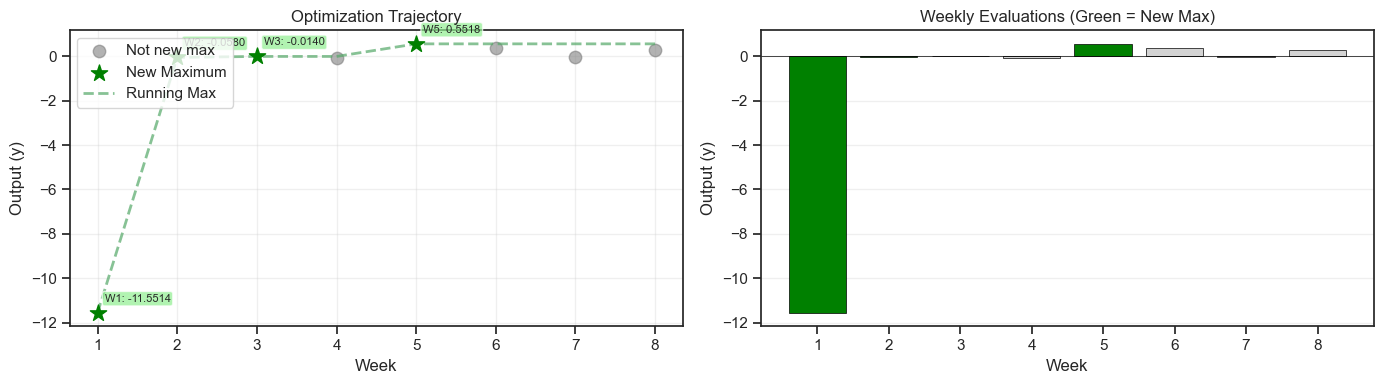

In [23]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Thompson Sampling for Noisy Multi-Modal Landscape

The function is described as "full of local optima" and noisy. Thompson Sampling handles this by:
1. Fitting a GP with explicit noise modeling
2. Drawing random samples from the posterior (not just using the mean)
3. Picking points that look promising across multiple samples

This naturally balances exploration and exploitation without getting trapped.


In [24]:
# Thompson Sampling for noisy, multi-modal optimization
# ======================================================
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Current best point
best_idx = df['y'].idxmax()
best_point = df.loc[best_idx]
best_x1, best_x2, best_x3, best_x4 = best_point['x1'], best_point['x2'], best_point['x3'], best_point['x4']
best_y = best_point['y']

print(f"Current best: ({best_x1:.4f}, {best_x2:.4f}, {best_x3:.4f}, {best_x4:.4f}) = {best_y:.4f}")
print(f"Week 8 point: (0.4369, 0.3400, 0.3800, 0.4072) = 0.262\n")
print("Note: Function is 'full of local optima' — we might be in a local trap!\n")

# Search region: moderate width to allow escape from potential local optimum
search_radius = 0.05  # ±0.05 in each dimension (wider than tight TuRBO)
sr_x1_min, sr_x1_max = max(0, best_x1 - search_radius), min(1, best_x1 + search_radius)
sr_x2_min, sr_x2_max = max(0, best_x2 - search_radius), min(1, best_x2 + search_radius)
sr_x3_min, sr_x3_max = max(0, best_x3 - search_radius), min(1, best_x3 + search_radius)
sr_x4_min, sr_x4_max = max(0, best_x4 - search_radius), min(1, best_x4 + search_radius)

print(f"Search region (±{search_radius}):")
print(f"  x1 ∈ [{sr_x1_min:.3f}, {sr_x1_max:.3f}]")
print(f"  x2 ∈ [{sr_x2_min:.3f}, {sr_x2_max:.3f}]")
print(f"  x3 ∈ [{sr_x3_min:.3f}, {sr_x3_max:.3f}]")
print(f"  x4 ∈ [{sr_x4_min:.3f}, {sr_x4_max:.3f}]\n")

# Fit GP with higher noise tolerance (function is noisy!)
kernel = (
    ConstantKernel(1.0, (1e-2, 100.0))
    * Matern(length_scale=[0.1, 0.1, 0.1, 0.1], length_scale_bounds=(0.01, 0.5), nu=2.5)
    + WhiteKernel(noise_level=0.1, noise_level_bounds=(0.01, 1.0))  # High noise!
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)
print(f"GP fitted. Kernel: {gp.kernel_}\n")

# Generate candidate grid within search region
grid_res = 12  # 12^4 = 20,736 candidates
grid_x1 = np.linspace(sr_x1_min, sr_x1_max, grid_res)
grid_x2 = np.linspace(sr_x2_min, sr_x2_max, grid_res)
grid_x3 = np.linspace(sr_x3_min, sr_x3_max, grid_res)
grid_x4 = np.linspace(sr_x4_min, sr_x4_max, grid_res)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3, grid_x4)).reshape(4, -1).T

print(f"Evaluating {len(mesh)} candidates...")

# Get GP predictions (mean and std)
mu, sigma = gp.predict(mesh, return_std=True)

# Thompson Sampling: draw multiple posterior samples, count wins
n_samples = 50
np.random.seed(42)
win_counts = np.zeros(len(mesh))

for _ in range(n_samples):
    # Sample from posterior: y_sample ~ N(mu, sigma^2)
    samples = mu + sigma * np.random.randn(len(mesh))
    winner = np.argmax(samples)
    win_counts[winner] += 1

print(f"Thompson Sampling: drew {n_samples} posterior samples")

# Build candidate dataframe
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4'])
candidates['mu'] = mu
candidates['sigma'] = sigma
candidates['wins'] = win_counts
candidates['win_rate'] = win_counts / n_samples

# Filter 1: must be at least 0.015 away from any existing observation
min_dist = 0.015
for _, obs in df.iterrows():
    dist = np.sqrt((candidates['x1'] - obs['x1'])**2 + 
                   (candidates['x2'] - obs['x2'])**2 +
                   (candidates['x3'] - obs['x3'])**2 +
                   (candidates['x4'] - obs['x4'])**2)
    candidates = candidates[dist >= min_dist]

print(f"Candidates after distance filter (≥{min_dist} from obs): {len(candidates)}")

# Filter 2: GP mean must be reasonable (not too far below best)
# Without this, Thompson Sampling picks high-uncertainty edges with terrible expected values
mu_threshold = best_y - 0.5  # Don't consider candidates with mu more than 0.5 below best
candidates_filtered = candidates[candidates['mu'] >= mu_threshold].copy()
print(f"Candidates after GP mean filter (μ ≥ {mu_threshold:.2f}): {len(candidates_filtered)}")

# If no candidates pass the mean filter, fall back to UCB ranking on all candidates
if len(candidates_filtered) < 5:
    print("\\nWarning: Few candidates pass mean filter. Using UCB ranking instead.")
    candidates['ucb'] = candidates['mu'] + 0.5 * candidates['sigma']
    top_candidates = candidates.nlargest(10, 'ucb')
    print("\\nTop 10 candidates (by UCB, since Thompson Sampling was too exploratory):")
else:
    # Re-run Thompson Sampling on filtered candidates only
    candidates_filtered['wins'] = 0
    mesh_filtered = candidates_filtered[['x1', 'x2', 'x3', 'x4']].values
    mu_filtered = candidates_filtered['mu'].values
    sigma_filtered = candidates_filtered['sigma'].values
    
    win_counts_filtered = np.zeros(len(candidates_filtered))
    for _ in range(n_samples):
        samples = mu_filtered + sigma_filtered * np.random.randn(len(mu_filtered))
        winner = np.argmax(samples)
        win_counts_filtered[winner] += 1
    
    candidates_filtered['wins'] = win_counts_filtered
    candidates_filtered['win_rate'] = win_counts_filtered / n_samples
    top_candidates = candidates_filtered.nlargest(10, 'wins')
    print("\\nTop 10 Thompson Sampling candidates (filtered, by win count):")

display(top_candidates)

# Recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    print(f"\n" + "="*60)
    print("THOMPSON SAMPLING RECOMMENDATION")
    print("="*60)
    print(f"Recommended point: ({rec['x1']:.6f}, {rec['x2']:.6f}, {rec['x3']:.6f}, {rec['x4']:.6f})")
    print(f"GP prediction: μ={rec['mu']:.4f}, σ={rec['sigma']:.4f}")
    print(f"Win rate: {rec['win_rate']:.1%} ({int(rec['wins'])}/{n_samples} samples)")
    print(f"\nSubmission format: {rec['x1']:.6f}-{rec['x2']:.6f}-{rec['x3']:.6f}-{rec['x4']:.6f}")
else:
    print("\nNo valid candidates found - try expanding search region")


Current best: (0.4303, 0.3593, 0.3518, 0.3837) = 0.5518
Week 8 point: (0.4369, 0.3400, 0.3800, 0.4072) = 0.262

Note: Function is 'full of local optima' — we might be in a local trap!

Search region (±0.05):
  x1 ∈ [0.380, 0.480]
  x2 ∈ [0.309, 0.409]
  x3 ∈ [0.302, 0.402]
  x4 ∈ [0.334, 0.434]

GP fitted. Kernel: 0.861**2 * Matern(length_scale=[0.5, 0.5, 0.5, 0.5], nu=2.5) + WhiteKernel(noise_level=0.01)

Evaluating 20736 candidates...
Thompson Sampling: drew 50 posterior samples
Candidates after distance filter (≥0.015 from obs): 20617
Candidates after GP mean filter (μ ≥ 0.05): 4085
\nTop 10 Thompson Sampling candidates (filtered, by win count):


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 0.5. Increasing the bound and calling fit again may find a bette

,x1,x2,x3,x4,mu,sigma,wins,win_rate
9043,0.398482,0.354755,0.383618,0.397336,0.075604,1.135036,1.0,0.02
9632,0.434845,0.354755,0.392709,0.406427,0.155972,1.103324,1.0,0.02
9642,0.434845,0.354755,0.401800,0.388245,0.079461,1.136663,1.0,0.02
11363,0.434845,0.363845,0.392709,0.433700,0.167104,1.135609,1.0,0.02
11620,0.453027,0.363845,0.374527,0.370064,0.062052,1.074988,1.0,0.02
11912,0.471209,0.363845,0.374527,0.406427,0.098353,1.121172,1.0,0.02
12353,0.389391,0.372936,0.383618,0.379155,0.062829,1.164225,1.0,0.02
12454,0.398482,0.372936,0.347255,0.424609,0.078972,1.110082,1.0,0.02
12489,0.398482,0.372936,0.374527,0.415518,0.191595,1.086802,1.0,0.02
13102,0.434845,0.372936,0.401800,0.424609,0.218676,1.120081,1.0,0.02



THOMPSON SAMPLING RECOMMENDATION
Recommended point: (0.398482, 0.354755, 0.383618, 0.397336)
GP prediction: μ=0.0756, σ=1.1350
Win rate: 2.0% (1/50 samples)

Submission format: 0.398482-0.354755-0.383618-0.397336


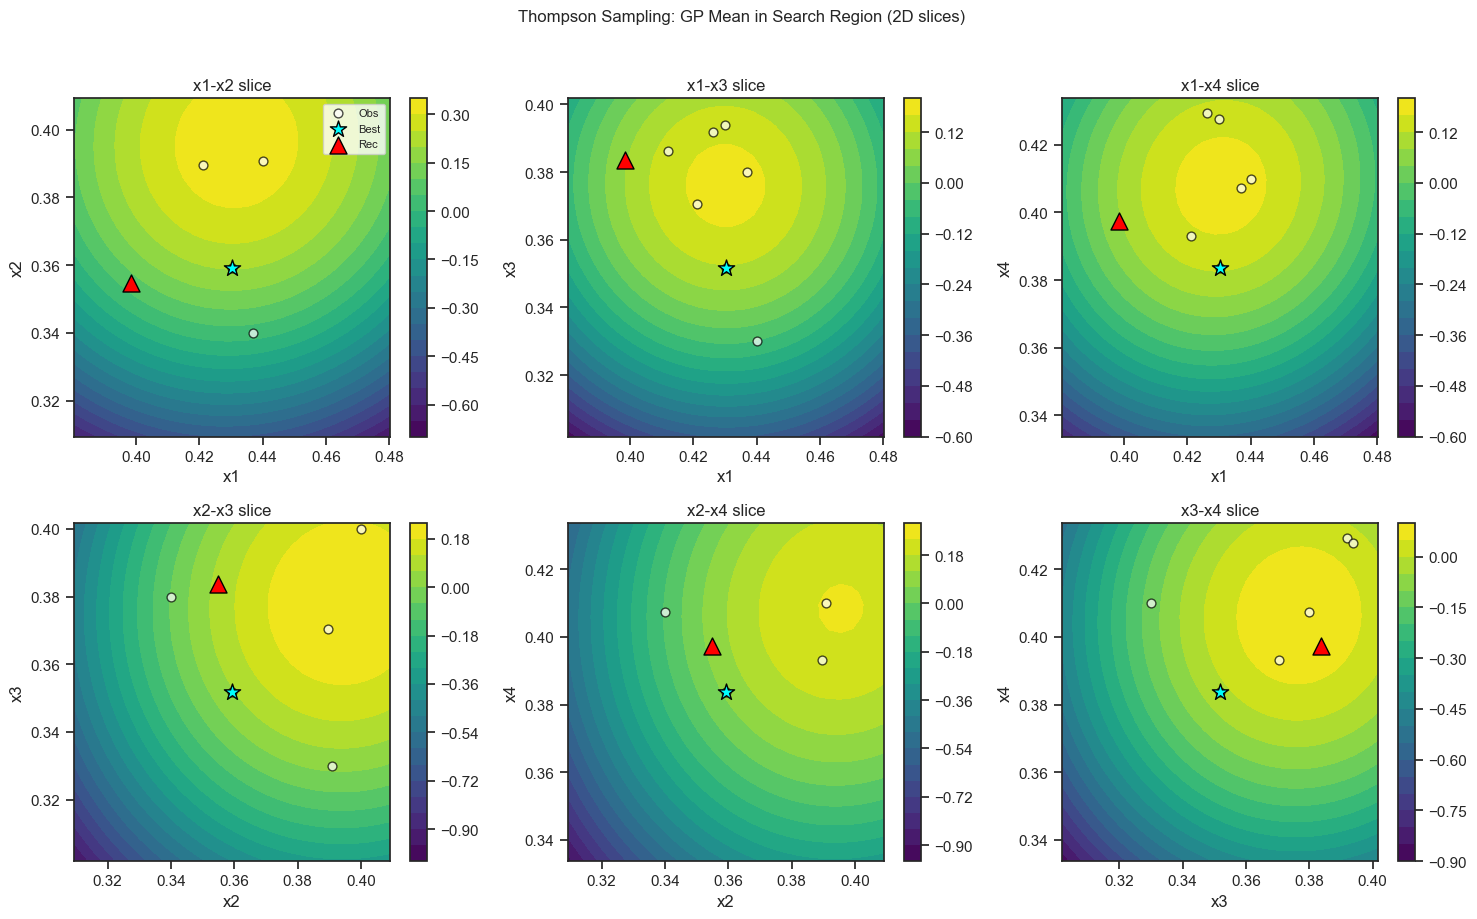

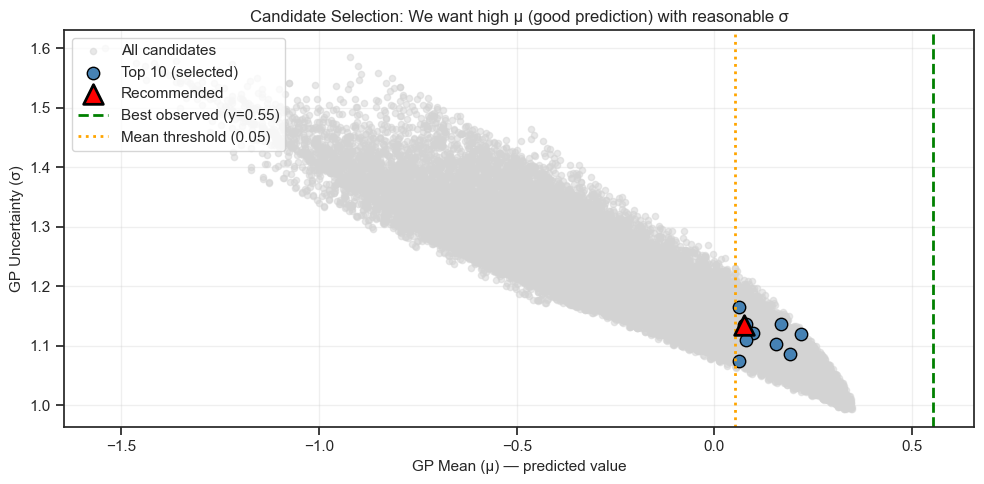

In [ ]:
# Visualization: Thompson Sampling results
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Get recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    rec_x = {'x1': rec['x1'], 'x2': rec['x2'], 'x3': rec['x3'], 'x4': rec['x4']}
else:
    rec_x = {'x1': best_x1, 'x2': best_x2, 'x3': best_x3, 'x4': best_x4}

# 6 pairwise 2D slices
pairs = [(0, 1, 'x1', 'x2'), (0, 2, 'x1', 'x3'), (0, 3, 'x1', 'x4'),
         (1, 2, 'x2', 'x3'), (1, 3, 'x2', 'x4'), (2, 3, 'x3', 'x4')]

sr_bounds = {'x1': (sr_x1_min, sr_x1_max), 'x2': (sr_x2_min, sr_x2_max), 
             'x3': (sr_x3_min, sr_x3_max), 'x4': (sr_x4_min, sr_x4_max)}

for ax_idx, (i, j, label_i, label_j) in enumerate(pairs):
    ax = axes[ax_idx]
    
    # Create 2D grid for this pair
    slice_res = 30
    xi_grid = np.linspace(sr_bounds[label_i][0], sr_bounds[label_i][1], slice_res)
    xj_grid = np.linspace(sr_bounds[label_j][0], sr_bounds[label_j][1], slice_res)
    xxi, xxj = np.meshgrid(xi_grid, xj_grid)
    
    # Build full 4D points for prediction (use column order: x1, x2, x3, x4)
    slice_pts = np.zeros((slice_res * slice_res, 4))
    col_map = {'x1': 0, 'x2': 1, 'x3': 2, 'x4': 3}
    slice_pts[:, col_map[label_i]] = xxi.ravel()
    slice_pts[:, col_map[label_j]] = xxj.ravel()
    for col_name in ['x1', 'x2', 'x3', 'x4']:
        if col_name != label_i and col_name != label_j:
            slice_pts[:, col_map[col_name]] = rec_x[col_name]
    
    slice_mu = gp.predict(slice_pts).reshape(xxi.shape)
    
    im = ax.contourf(xxi, xxj, slice_mu, levels=20, cmap='viridis')
    
    # Plot all observations (use column names directly)
    ax.scatter(df[label_i], df[label_j], c='white', edgecolor='black', s=40, alpha=0.7, label='Obs')
    ax.scatter(best_point[label_i], best_point[label_j], c='cyan', edgecolor='black', s=150, marker='*', label='Best')
    ax.scatter(rec_x[label_i], rec_x[label_j], c='red', edgecolor='black', s=150, marker='^', label='Rec')
    
    # Set axis limits to search region
    ax.set_xlim(sr_bounds[label_i])
    ax.set_ylim(sr_bounds[label_j])
    ax.set_xlabel(label_i)
    ax.set_ylabel(label_j)
    ax.set_title(f'{label_i}-{label_j} slice')
    plt.colorbar(im, ax=ax)

axes[0].legend(fontsize=8, loc='upper right')
plt.suptitle('Thompson Sampling: GP Mean in Search Region (2D slices)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Show GP mean vs uncertainty for candidates (more informative than win rate bar chart)
fig2, ax2 = plt.subplots(figsize=(10, 5))

# Plot all candidates that passed distance filter
ax2.scatter(candidates['mu'], candidates['sigma'], c='lightgray', s=20, alpha=0.5, label='All candidates')

# Highlight top candidates
ax2.scatter(top_candidates['mu'], top_candidates['sigma'], c='steelblue', s=80, edgecolor='black', label='Top 10 (selected)')

# Mark the recommended point
if len(top_candidates) > 0:
    rec = top_candidates.iloc[0]
    ax2.scatter(rec['mu'], rec['sigma'], c='red', s=200, marker='^', edgecolor='black', linewidth=2, label='Recommended', zorder=10)

# Mark the best observed y value
ax2.axvline(x=best_y, color='green', linestyle='--', linewidth=2, label=f'Best observed (y={best_y:.2f})')

# Add reference line for mean threshold if it was applied
if 'mu_threshold' in dir():
    ax2.axvline(x=mu_threshold, color='orange', linestyle=':', linewidth=2, label=f'Mean threshold ({mu_threshold:.2f})')

ax2.set_xlabel('GP Mean (μ) — predicted value', fontsize=11)
ax2.set_ylabel('GP Uncertainty (σ)', fontsize=11)
ax2.set_title('Candidate Selection: We want high μ (good prediction) with reasonable σ', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary and Recommended Point for Week 9

### What happened in Week 8
We probed `(0.4369, 0.3400, 0.3800, 0.4072)` and got `y ≈ 0.262` — a big drop from our best 0.5518.

### Rethinking the problem
My first instinct was "narrow peak" — but the function description says **"full of local optima."** The drop could be:
- Noise (the function is noisy)
- We stepped into a different local basin
- Or yes, possibly a narrow peak

If I go too tight (like ±0.015 TuRBO), I risk getting **trapped in a local optimum**. The 0.5518 point might not even be the global max!

### Why Thompson Sampling this week
Thompson Sampling is designed for noisy, multi-modal landscapes:
- It samples from the GP posterior instead of just using the mean
- Naturally balances exploration and exploitation
- Can escape local optima by occasionally picking "surprising" points

I used a **wider search region (±0.05)** to allow escape from a potential local trap, with high noise tolerance in the GP.

**Important refinement:** Pure Thompson Sampling can be *too* exploratory — it might pick high-uncertainty edges with terrible expected values (like μ = -0.9 when our best is 0.55). So I filter out candidates where GP mean is much worse than best before running Thompson Sampling.

### Recommended point

**Submission format:** Check the Thompson Sampling output cell above — it prints the exact coordinates.

The point is the most frequent winner across 50 posterior samples, filtered to only include candidates with reasonable GP mean (μ ≥ best - 0.5), and at least 0.015 away from existing observations.

### Honest assessment
With 39 observations and "full of local optima," we might be chasing ghosts. The 0.5518 could be a lucky local max. Thompson Sampling gives us the best chance of finding something better without getting stuck.
